# Proyecto 5: Estrategia de ventas data-driven

Caso: tienda online de productos electrónicos.

Este notebook transforma datos transaccionales en decisiones de negocio con evidencia cuantitativa para:
- promociones comerciales,
- bono por satisfacción,
- priorización de clientes,
- gestión de portafolio de productos.

## Estructura del notebook
1. Configuración e imports
2. Carga y auditoría de datos
3. Feature engineering
4. EDA para negocio
5. Inferencia para decisiones gerenciales
6. Segmentación de clientes con clustering
7. Recomendaciones estratégicas

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp, shapiro, binomtest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
np.random.seed(42)

In [53]:
PROJECT_DIR = Path.cwd() / "Semana_2_Proyecto_5"
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()

DATA_PATH = PROJECT_DIR / "ventas_data_driven.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / "Semana_2_Proyecto_5" / "ventas_data_driven.csv"

assert DATA_PATH.exists(), f"No se encontró el dataset en: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, sep=";")
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

for col in ["Cantidad", "Precio", "Total", "Descuento", "Agrado", "Sugerencia"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Ruta de datos: {DATA_PATH}")
print(f"Filas y columnas: {df.shape}")
display(df.head())

Ruta de datos: c:\GitHub\Analitica-Negocios\Semana_2_Proyecto_5\ventas_data_driven.csv
Filas y columnas: (100, 11)


,OrderID,CustomerID,Product,Cantidad,Precio,Total,Descuento,Agrado,Sugerencia,Fecha,Zona
0,O0001,C052,Producto_6,3,165,495,19.03,5.61,5.84,2024-05-13,Este
1,O0002,C026,Producto_7,3,112,336,25.09,6.74,8.79,2024-07-21,Centro
2,O0003,C131,Producto_6,1,219,219,18.24,6.05,7.52,2024-01-18,Centro
3,O0004,C061,Producto_6,3,248,744,22.66,7.34,4.14,2024-05-08,Centro
4,O0005,C149,Producto_10,5,63,315,17.92,6.50,6.19,2024-12-05,Centro


In [54]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "n_unicos": df.nunique()
}).sort_values(["nulos", "n_unicos"], ascending=[False, False])

duplicados_completos = int(df.duplicated().sum())
duplicados_orderid = int(df["OrderID"].duplicated().sum())

df["total_recalculado"] = df["Cantidad"] * df["Precio"]
df["dif_total"] = (df["Total"] - df["total_recalculado"]).abs()
inconsistencias_total = int((df["dif_total"] > 1e-9).sum())

print(f"Nulos totales: {int(df.isna().sum().sum())}")
print(f"Duplicados completos: {duplicados_completos}")
print(f"OrderID duplicados: {duplicados_orderid}")
print(f"Inconsistencias Total vs Cantidad*Precio: {inconsistencias_total}")
display(resumen_calidad)

Nulos totales: 0
Duplicados completos: 0
OrderID duplicados: 0
Inconsistencias Total vs Cantidad*Precio: 0


,tipo,nulos,n_unicos
OrderID,str,0,100
Descuento,float64,0,100
Agrado,float64,0,100
Sugerencia,float64,0,99
Total,int64,0,95
Precio,int64,0,90
Fecha,datetime64[us],0,86
CustomerID,str,0,71
Product,str,0,10
Cantidad,int64,0,5


In [55]:
df["descuento_pct"] = df["Descuento"] / 100.0
df["descuento_monto"] = df["Total"] * df["descuento_pct"]
df["ingreso_neto"] = df["Total"] - df["descuento_monto"]

df["anio"] = df["Fecha"].dt.year
df["mes"] = df["Fecha"].dt.to_period("M").astype(str)
df["mes_num"] = df["Fecha"].dt.month
df["trimestre"] = "Q" + df["Fecha"].dt.quarter.astype(str)

fecha_corte = df["Fecha"].max()

customer_summary = (
    df.groupby("CustomerID", as_index=False)
      .agg(
          ordenes=("OrderID", "nunique"),
          ingreso_bruto_total=("Total", "sum"),
          ingreso_neto_total=("ingreso_neto", "sum"),
          ticket_bruto_prom=("Total", "mean"),
          ticket_neto_prom=("ingreso_neto", "mean"),
          descuento_prom=("Descuento", "mean"),
          agrado_prom=("Agrado", "mean"),
          sugerencia_prom=("Sugerencia", "mean"),
          diversidad_productos=("Product", "nunique"),
          ultima_compra=("Fecha", "max")
      )
)

customer_summary["recencia_dias"] = (fecha_corte - customer_summary["ultima_compra"]).dt.days
customer_summary["satisfaccion_alta"] = (customer_summary["agrado_prom"] > 7).astype(int)

print(f"Clientes únicos: {customer_summary['CustomerID'].nunique()}")
display(customer_summary.head())

Clientes únicos: 71


,CustomerID,ordenes,ingreso_bruto_total,ingreso_neto_total,ticket_bruto_prom,ticket_neto_prom,descuento_prom,agrado_prom,sugerencia_prom,diversidad_productos,ultima_compra,recencia_dias,satisfaccion_alta
0,C002,2,2548,"2,090.97","1,274.00","1,045.48",17.54,8.12,8.14,2,2024-06-29,183,1
1,C003,2,1072,861.83,536.00,430.91,20.12,4.79,8.27,2,2024-12-11,18,0
2,C004,1,360,288.39,360.00,288.39,19.89,7.80,5.80,1,2024-05-01,242,1
3,C006,1,1335,"1,103.92","1,335.00","1,103.92",17.31,5.03,8.13,1,2024-07-30,152,0
4,C007,1,70,58.50,70.00,58.50,16.43,6.18,6.97,1,2024-02-04,329,0


## EDA para responder preguntas de negocio

Top productos por ingreso neto:


,Product,ingreso_neto,ingreso_bruto,unidades,ordenes
1,Producto_10,"12,322.86",14814,48,15
8,Producto_8,"11,238.53",13233,47,15
5,Producto_5,"9,258.00",11395,37,12
0,Producto_1,"7,940.73",9660,33,10
4,Producto_4,"6,239.81",7784,23,6
9,Producto_9,"6,146.82",7264,29,9
7,Producto_7,"5,826.63",7029,29,10
6,Producto_6,"4,748.27",5861,21,8
3,Producto_3,"3,376.81",4091,22,9
2,Producto_2,"3,080.11",3794,16,6


Productos con menor ingreso neto:


,Product,ingreso_neto,ingreso_bruto,unidades,ordenes
2,Producto_2,"3,080.11",3794,16,6
3,Producto_3,"3,376.81",4091,22,9
6,Producto_6,"4,748.27",5861,21,8
7,Producto_7,"5,826.63",7029,29,10
9,Producto_9,"6,146.82",7264,29,9


Clientes más frecuentes:


,CustomerID,ordenes,ingreso_bruto_total,ingreso_neto_total,ticket_bruto_prom,ticket_neto_prom,descuento_prom,agrado_prom,sugerencia_prom,diversidad_productos,ultima_compra,recencia_dias,satisfaccion_alta
37,C081,4,5245,"4,367.49","1,311.25","1,091.87",17.28,5.72,6.90,3,2024-11-23,36,0
31,C067,3,2515,"2,063.95",838.33,687.98,16.31,7.13,7.28,3,2024-09-12,108,1
38,C085,3,2210,"1,965.88",736.67,655.29,11.54,4.99,8.06,2,2024-10-06,84,0
28,C061,3,1563,"1,300.32",521.00,433.44,16.67,6.53,6.42,3,2024-12-29,0,0
48,C100,3,1023,867.11,341.00,289.04,14.36,5.95,7.03,3,2024-11-16,43,0
66,C137,3,456,385.38,152.00,128.46,16.43,5.78,7.34,3,2024-12-09,20,0
15,C038,2,3088,"2,429.64","1,544.00","1,214.82",20.53,6.95,6.94,2,2024-06-24,188,0
49,C101,2,2654,"2,386.17","1,327.00","1,193.09",9.95,3.86,7.40,2,2024-09-22,98,0
23,C052,2,2795,"2,289.47","1,397.50","1,144.74",18.46,5.26,6.26,2,2024-05-13,230,0
47,C097,2,2801,"2,268.33","1,400.50","1,134.16",17.43,4.75,7.35,2,2024-07-24,158,0


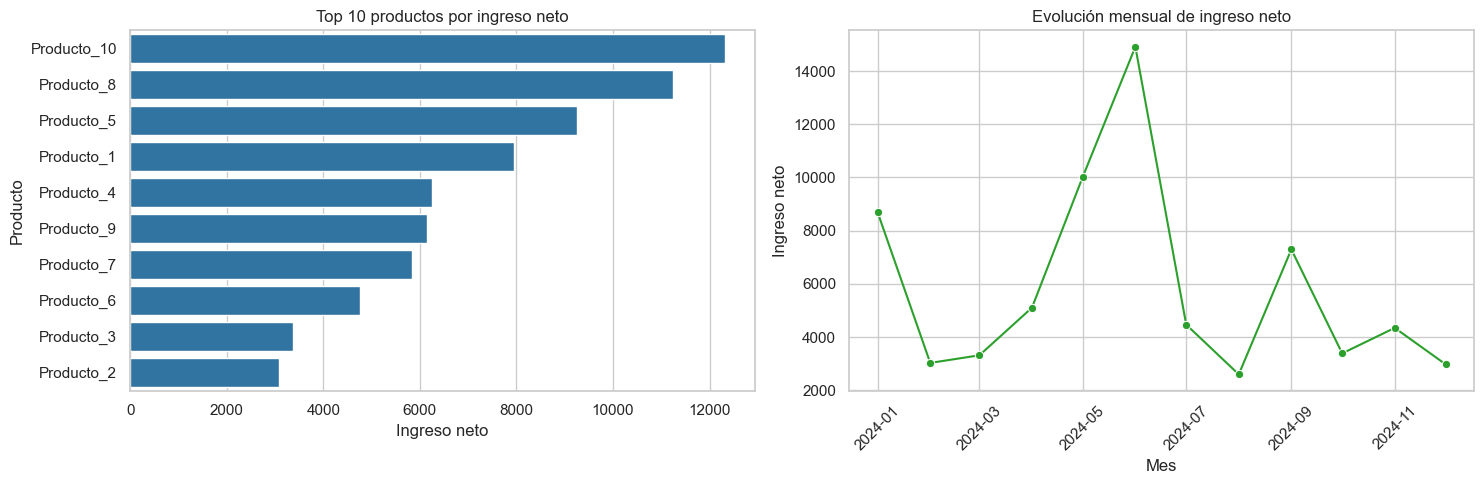

In [56]:
ingresos_producto = (
    df.groupby("Product", as_index=False)
      .agg(
          ingreso_neto=("ingreso_neto", "sum"),
          ingreso_bruto=("Total", "sum"),
          unidades=("Cantidad", "sum"),
          ordenes=("OrderID", "nunique")
      )
      .sort_values("ingreso_neto", ascending=False)
)

ventas_mes = (
    df.groupby("mes", as_index=False)
      .agg(
          ingreso_neto=("ingreso_neto", "sum"),
          ingreso_bruto=("Total", "sum"),
          ordenes=("OrderID", "nunique")
      )
)
ventas_mes["mes_dt"] = pd.to_datetime(ventas_mes["mes"] + "-01")
ventas_mes = ventas_mes.sort_values("mes_dt")

clientes_frecuentes = customer_summary.sort_values(["ordenes", "ingreso_neto_total"], ascending=False).head(10)

print("Top productos por ingreso neto:")
display(ingresos_producto.head(10))
print("Productos con menor ingreso neto:")
display(ingresos_producto.tail(5).sort_values("ingreso_neto"))
print("Clientes más frecuentes:")
display(clientes_frecuentes)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=ingresos_producto.head(10), x="ingreso_neto", y="Product", ax=axes[0], color="#1f77b4")
axes[0].set_title("Top 10 productos por ingreso neto")
axes[0].set_xlabel("Ingreso neto")
axes[0].set_ylabel("Producto")

sns.lineplot(data=ventas_mes, x="mes_dt", y="ingreso_neto", marker="o", ax=axes[1], color="#2ca02c")
axes[1].set_title("Evolución mensual de ingreso neto")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Ingreso neto")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Inferencia estadística para decisiones gerenciales

In [57]:
# Decisión 1: promociones si el promedio de ventas por cliente supera 700 soles.
# Unidad de análisis: cliente agregado (ingreso neto total por cliente).

muestra_promocion = customer_summary["ingreso_neto_total"].dropna()

if 3 <= len(muestra_promocion) <= 5000:
    stat_shapiro, p_shapiro = shapiro(muestra_promocion)
else:
    stat_shapiro, p_shapiro = np.nan, np.nan

ttest_res = ttest_1samp(muestra_promocion, popmean=700, alternative="greater")

rng = np.random.default_rng(42)
boot_means = np.array([
    rng.choice(muestra_promocion.to_numpy(), size=len(muestra_promocion), replace=True).mean()
    for _ in range(5000)
])
ci_boot_low, ci_boot_high = np.percentile(boot_means, [2.5, 97.5])

decision_promocion = "SI" if (ttest_res.pvalue < 0.05 and muestra_promocion.mean() > 700) else "NO"

resumen_promocion = pd.Series({
    "n_clientes": len(muestra_promocion),
    "media_muestral": muestra_promocion.mean(),
    "mediana_muestral": muestra_promocion.median(),
    "shapiro_pvalue": p_shapiro,
    "t_stat": ttest_res.statistic,
    "t_pvalue": ttest_res.pvalue,
    "ci_boot_95_low": ci_boot_low,
    "ci_boot_95_high": ci_boot_high,
    "decision_promociones": decision_promocion
})

display(resumen_promocion.to_frame("valor"))

,valor
n_clientes,71
media_muestral,988.43
mediana_muestral,867.11
shapiro_pvalue,0.00
t_stat,2.99
t_pvalue,0.00
ci_boot_95_low,811.88
ci_boot_95_high,"1,184.13"
decision_promociones,SI


In [58]:
# Decisión 2: bono si la proporción de clientes con satisfacción > 7 supera 23%.

exitos = int((customer_summary["agrado_prom"] > 7).sum())
n_clientes = int(customer_summary.shape[0])
prop_observada = exitos / n_clientes if n_clientes > 0 else np.nan

binom_res = binomtest(exitos, n=n_clientes, p=0.23, alternative="greater")
ci_prop = binom_res.proportion_ci(confidence_level=0.95, method="exact")

decision_bono = "SI" if (binom_res.pvalue < 0.05 and prop_observada > 0.23) else "NO"

resumen_bono = pd.Series({
    "clientes_exito": exitos,
    "n_clientes": n_clientes,
    "proporcion_observada": prop_observada,
    "hipotesis_umbral": 0.23,
    "binom_pvalue": binom_res.pvalue,
    "ic_95_low": ci_prop.low,
    "ic_95_high": ci_prop.high,
    "decision_bono": decision_bono
})

display(resumen_bono.to_frame("valor"))

,valor
clientes_exito,14
n_clientes,71
proporcion_observada,0.20
hipotesis_umbral,0.23
binom_pvalue,0.78
ic_95_low,0.12
ic_95_high,1.00
decision_bono,NO


## Segmentación de clientes con clustering

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.31,31.45,1.27
1,3,0.28,28.04,1.21
2,4,0.27,22.80,1.32
3,5,0.29,26.01,1.28
4,6,0.26,22.77,1.32


Mejor k según silhouette: 2


,cluster,clientes,ingreso_neto_prom,ordenes_prom,recencia_prom,agrado_prom,descuento_prom
0,0,21,"1,739.40",2.33,111.95,5.80,16.49
1,1,50,673.02,1.02,203.90,6.07,17.59


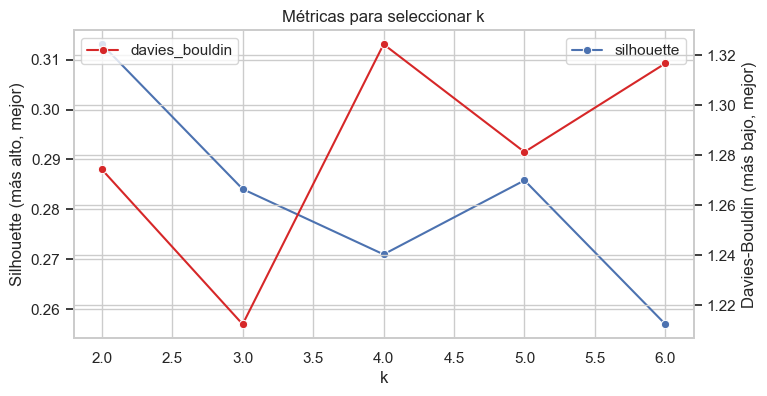

In [59]:
features_cluster = [
    "recencia_dias",
    "ordenes",
    "ingreso_neto_total",
    "ticket_neto_prom",
    "descuento_prom",
    "agrado_prom",
    "diversidad_productos"
]

cluster_df = customer_summary[["CustomerID"] + features_cluster].dropna().copy()
X = cluster_df[features_cluster].copy()

metricas_k = []
if len(cluster_df) >= 6:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for k in range(2, 7):
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = model.fit_predict(X_scaled)
        metricas_k.append({
            "k": k,
            "silhouette": silhouette_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels)
        })

    metricas_k = pd.DataFrame(metricas_k).sort_values("k")
    best_k = int(metricas_k.sort_values("silhouette", ascending=False).iloc[0]["k"])

    modelo_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    cluster_df["cluster"] = modelo_final.fit_predict(X_scaled)

    customer_summary = customer_summary.merge(cluster_df[["CustomerID", "cluster"]], on="CustomerID", how="left")

    perfil_cluster = (
        customer_summary.groupby("cluster", as_index=False)
        .agg(
            clientes=("CustomerID", "nunique"),
            ingreso_neto_prom=("ingreso_neto_total", "mean"),
            ordenes_prom=("ordenes", "mean"),
            recencia_prom=("recencia_dias", "mean"),
            agrado_prom=("agrado_prom", "mean"),
            descuento_prom=("descuento_prom", "mean")
        )
        .sort_values("ingreso_neto_prom", ascending=False)
    )

    display(metricas_k)
    print(f"Mejor k según silhouette: {best_k}")
    display(perfil_cluster)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.lineplot(data=metricas_k, x="k", y="silhouette", marker="o", ax=ax, label="silhouette")
    ax2 = ax.twinx()
    sns.lineplot(data=metricas_k, x="k", y="davies_bouldin", marker="o", color="#d62728", ax=ax2, label="davies_bouldin")
    ax.set_title("Métricas para seleccionar k")
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette (más alto, mejor)")
    ax2.set_ylabel("Davies-Bouldin (más bajo, mejor)")
    plt.show()
else:
    print("No hay suficientes clientes para evaluar k de 2 a 6.")

In [60]:
q75_ingreso = customer_summary["ingreso_neto_total"].quantile(0.75)
q50_ingreso = customer_summary["ingreso_neto_total"].quantile(0.50)
q75_descuento = customer_summary["descuento_prom"].quantile(0.75)

clientes_vip_contacto = customer_summary[(customer_summary["ingreso_neto_total"] >= q75_ingreso) & (customer_summary["recencia_dias"] <= 60)]
clientes_recuperar = customer_summary[(customer_summary["ingreso_neto_total"] >= q50_ingreso) & (customer_summary["recencia_dias"] >= 90)]
clientes_desc_sensibles = customer_summary[customer_summary["descuento_prom"] >= q75_descuento]

top_productos = ingresos_producto.head(3)[["Product", "ingreso_neto"]]
bottom_productos = ingresos_producto.tail(3)[["Product", "ingreso_neto"]].sort_values("ingreso_neto")

n_vip = len(clientes_vip_contacto)
n_rec = len(clientes_recuperar)
n_desc = len(clientes_desc_sensibles)

txt_vip = f"{n_vip} cliente cumple criterio" if n_vip == 1 else f"{n_vip} clientes cumplen criterio"
txt_rec = f"{n_rec} cliente para recuperar" if n_rec == 1 else f"{n_rec} clientes para recuperar"
txt_desc = f"{n_desc} cliente con descuento promedio alto" if n_desc == 1 else f"{n_desc} clientes con descuento promedio alto"

acciones = pd.DataFrame([
    {
        "objetivo": "Campaña de fidelización VIP",
        "segmento": "Clientes de alto valor y compra reciente",
        "evidencia": txt_vip,
        "accion_recomendada": "Beneficio exclusivo por recompra en 30 días",
        "kpi": "Tasa de recompra a 30 días"
    },
    {
        "objetivo": "Campaña de reactivación",
        "segmento": "Clientes valiosos sin compra reciente",
        "evidencia": txt_rec,
        "accion_recomendada": "Oferta limitada y contacto directo",
        "kpi": "Win-back rate"
    },
    {
        "objetivo": "Optimizar promociones",
        "segmento": "Clientes sensibles al descuento",
        "evidencia": txt_desc,
        "accion_recomendada": "Cupones segmentados, no masivos",
        "kpi": "Margen neto por campaña"
    },
    {
        "objetivo": "Gestión de portafolio",
        "segmento": "Productos top y bottom",
        "evidencia": "Top y bottom por ingreso neto identificados",
        "accion_recomendada": "Destacar top en home y revisar posición de bottom",
        "kpi": "Participación de ingreso por producto"
    }
])

print("Top productos para destacar:")
display(top_productos)
print("Productos para revisar o retirar si no mejoran:")
display(bottom_productos)

print("Clientes para contacto directo (prioridad alta):")
display(clientes_vip_contacto.sort_values("ingreso_neto_total", ascending=False).head(15))

print("Plan de acciones estratégicas:")
display(acciones)

Top productos para destacar:


,Product,ingreso_neto
1,Producto_10,"12,322.86"
8,Producto_8,"11,238.53"
5,Producto_5,"9,258.00"


Productos para revisar o retirar si no mejoran:


,Product,ingreso_neto
2,Producto_2,"3,080.11"
3,Producto_3,"3,376.81"
6,Producto_6,"4,748.27"


Clientes para contacto directo (prioridad alta):


,CustomerID,ordenes,ingreso_bruto_total,ingreso_neto_total,ticket_bruto_prom,ticket_neto_prom,descuento_prom,agrado_prom,sugerencia_prom,diversidad_productos,ultima_compra,recencia_dias,satisfaccion_alta,cluster
37,C081,4,5245,"4,367.49","1,311.25","1,091.87",17.28,5.72,6.90,3,2024-11-23,36,0,0


Plan de acciones estratégicas:


,objetivo,segmento,evidencia,accion_recomendada,kpi
0,Campaña de fidelización VIP,Clientes de alto valor y compra reciente,1 cliente cumple criterio,Beneficio exclusivo por recompra en 30 días,Tasa de recompra a 30 días
1,Campaña de reactivación,Clientes valiosos sin compra reciente,27 clientes para recuperar,Oferta limitada y contacto directo,Win-back rate
2,Optimizar promociones,Clientes sensibles al descuento,18 clientes con descuento promedio alto,"Cupones segmentados, no masivos",Margen neto por campaña
3,Gestión de portafolio,Productos top y bottom,Top y bottom por ingreso neto identificados,Destacar top en home y revisar posición de bottom,Participación de ingreso por producto


## Resumen ejecutivo para gerencia

Interpretación de resultados del análisis actual:
- Decisión de promociones: SÍ, el promedio por cliente supera el umbral de 700 con soporte estadístico.
- Decisión de bono: NO, la proporción de clientes con agrado promedio mayor a 7 no supera 23% con alfa 0.05.
- Productos foco: priorizar los de mayor ingreso neto y rediseñar estrategia para los de menor aporte.
- Segmentos: usar clúster de alto valor para retención y clúster de menor valor para reactivación selectiva.

In [61]:
resumen_gerencial = pd.DataFrame([
    {
        "decision": "Promociones especiales",
        "resultado": decision_promocion,
        "indicador_clave": "Media de ingreso neto por cliente",
        "valor_observado": round(float(muestra_promocion.mean()), 2),
        "umbral": 700.0,
        "p_value": round(float(ttest_res.pvalue), 6)
    },
    {
        "decision": "Bono de reconocimiento",
        "resultado": decision_bono,
        "indicador_clave": "Proporción de clientes con agrado > 7",
        "valor_observado": round(float(prop_observada), 4),
        "umbral": 0.23,
        "p_value": round(float(binom_res.pvalue), 6)
    }
])

print("Tablero de decisión gerencial:")
display(resumen_gerencial)

print("Mensajes clave para comité:")
print(f"- Promociones: {decision_promocion} (media por cliente={muestra_promocion.mean():.2f}, p-value={ttest_res.pvalue:.6f}).")
print(f"- Bono: {decision_bono} (proporción={prop_observada:.4f}, p-value={binom_res.pvalue:.6f}).")
print("- Recomendación: ejecutar campañas segmentadas por valor de cliente y seguimiento mensual de KPIs.")

Tablero de decisión gerencial:


,decision,resultado,indicador_clave,valor_observado,umbral,p_value
0,Promociones especiales,SI,Media de ingreso neto por cliente,988.43,700.00,0.00
1,Bono de reconocimiento,NO,Proporción de clientes con agrado > 7,0.20,0.23,0.78


Mensajes clave para comité:
- Promociones: SI (media por cliente=988.43, p-value=0.001917).
- Bono: NO (proporción=0.1972, p-value=0.784820).
- Recomendación: ejecutar campañas segmentadas por valor de cliente y seguimiento mensual de KPIs.


## Cierre ejecutivo y plan 30-60-90

Limitaciones del análisis:
- Dataset de 1 año y 100 órdenes; los resultados deben validarse de forma continua.
- No se incluyen costos operativos ni margen por producto.
- La inferencia soporta decisión estadística, no causalidad comercial.

Plan de acción sugerido:
- 30 días: lanzar campaña de retención para clientes de alto valor y prueba de reactivación para clientes inactivos.
- 60 días: evaluar impacto por KPI (recompra, ingreso neto, margen por campaña).
- 90 días: ajustar portafolio de productos y actualizar segmentación con datos nuevos.